# Exercise 1

In [ ]:
# Versions used incase of any issues 
import sys 
import pkg_resources as pkg
print("Python:", sys.version)
print("numpy:", pkg.get_distribution("numpy").version)
print("pandas:", pkg.get_distribution("pandas").version)
print("scikit-learn:", pkg.get_distribution("scikit-learn").version)
print("matplotlib:", pkg.get_distribution("matplotlib").version)
print("seaborn", pkg.get_distribution("seaborn").version)
print("tensorflow:", pkg.get_distribution("tensorflow").version)
print("keras:", pkg.get_distribution("keras").version)

In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from seaborn import heatmap, histplot, pairplot, barplot

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

### Task 1

In [3]:
df = pd.read_csv("Country_Data.csv")
df.head()

,country,income,child_mortality,life_expectancy,health_exp,gdpp,education_index
0,Country_1,59.516847,5.000000,82.853065,3322.946051,55.382380,0.887083
1,Country_2,29.046532,19.916584,70.829731,1438.011786,22.069371,0.611301
2,Country_3,21.989635,28.062344,71.707952,1272.570648,18.886684,0.630639
3,Country_4,17.784780,25.476721,68.515032,1175.294320,26.660145,0.623375
4,Country_5,23.522533,21.516141,73.908315,1117.656228,18.047816,0.549015


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          105 non-null    object 
 1   income           105 non-null    float64
 2   child_mortality  105 non-null    float64
 3   life_expectancy  105 non-null    float64
 4   health_exp       105 non-null    float64
 5   gdpp             105 non-null    float64
 6   education_index  105 non-null    float64
dtypes: float64(6), object(1)
memory usage: 5.9+ KB


In [5]:
df.isnull().sum()

country            0
income             0
child_mortality    0
life_expectancy    0
health_exp         0
gdpp               0
education_index    0
dtype: int64

We see that there are no missing values

In [6]:
df.shape

(105, 7)

In [7]:
print("The dataset contains", df["country"].value_counts().sum(), "countries and 6 development-related metrics.")

The dataset contains 105 countries and 6 development-related metrics.


In [8]:
# Create a new dataset without the country variable 
df_only_numerical = df.drop(["country"], axis = 1)

### Task 2

In [9]:
df_only_numerical.describe()

,income,child_mortality,life_expectancy,health_exp,gdpp,education_index
count,105.000000,105.000000,105.000000,105.000000,105.000000,105.000000
mean,29.755490,27.609993,70.869355,1790.737304,28.803058,0.638645
std,20.090473,24.414428,9.541815,1376.546440,20.732316,0.222129
min,3.538087,5.000000,47.717587,82.284303,1.184385,0.151749
25%,15.694560,5.000000,68.240371,798.378161,12.318882,0.478626
50%,22.993972,23.779598,70.999728,1175.294320,22.581132,0.622986
75%,50.626559,30.225442,76.938816,3004.753682,45.745754,0.856296
max,68.387617,89.726707,91.819362,5291.155402,81.207931,1.023103


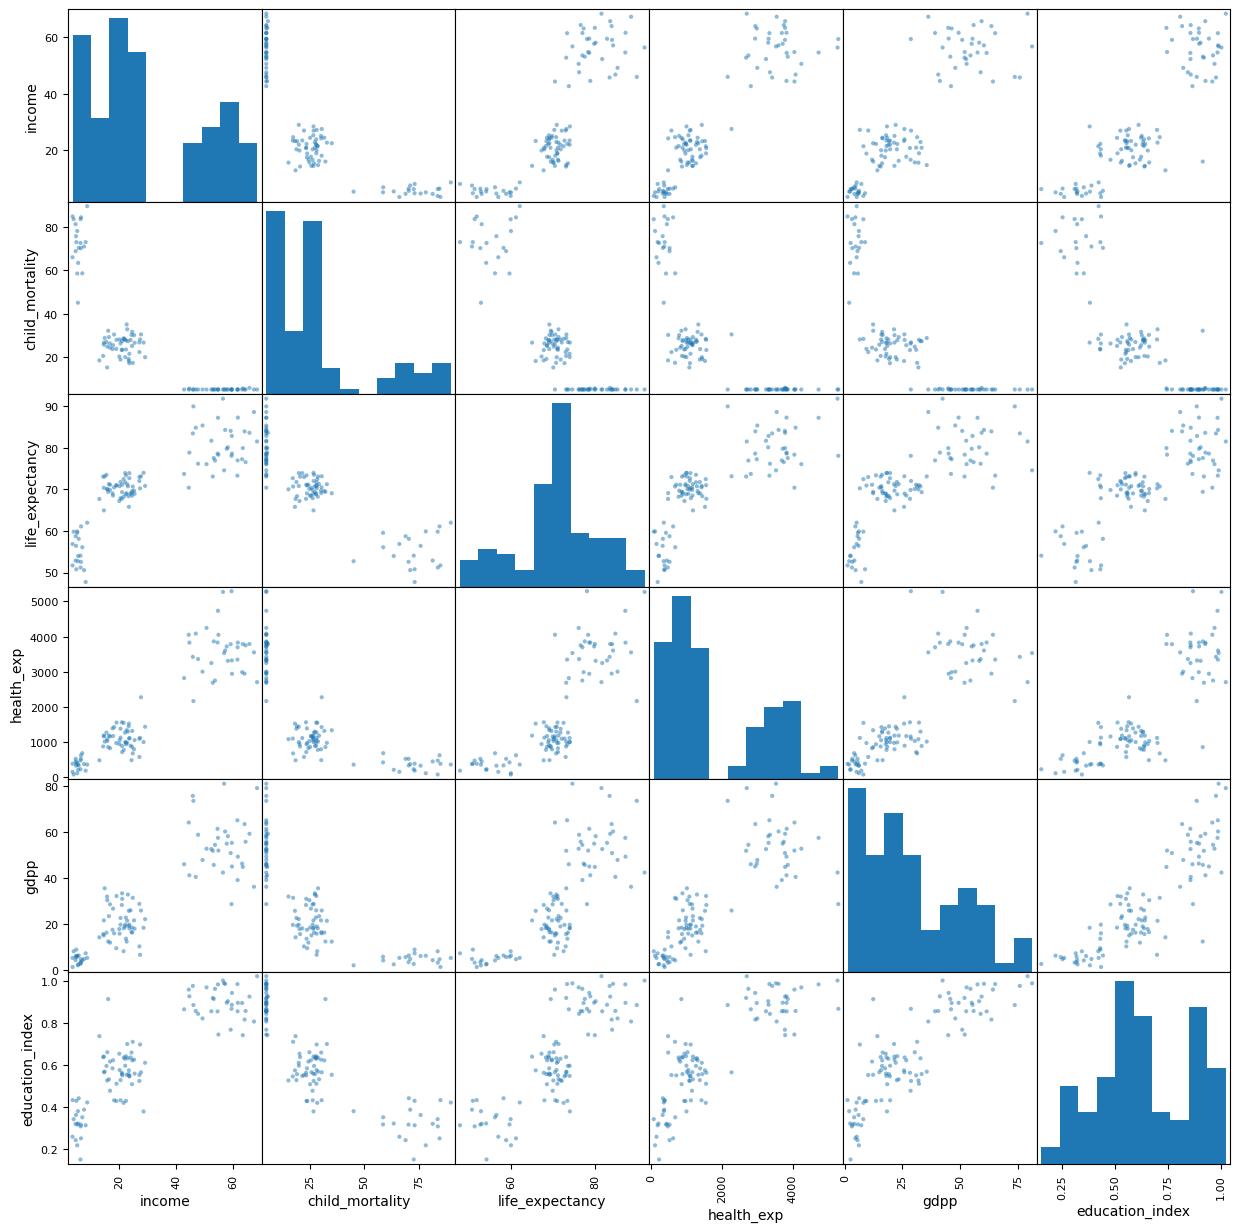

In [10]:
pd.plotting.scatter_matrix(df_only_numerical[["income", "child_mortality", "life_expectancy", "health_exp", "gdpp", "education_index"]], figsize = (15, 15))
plt.show()

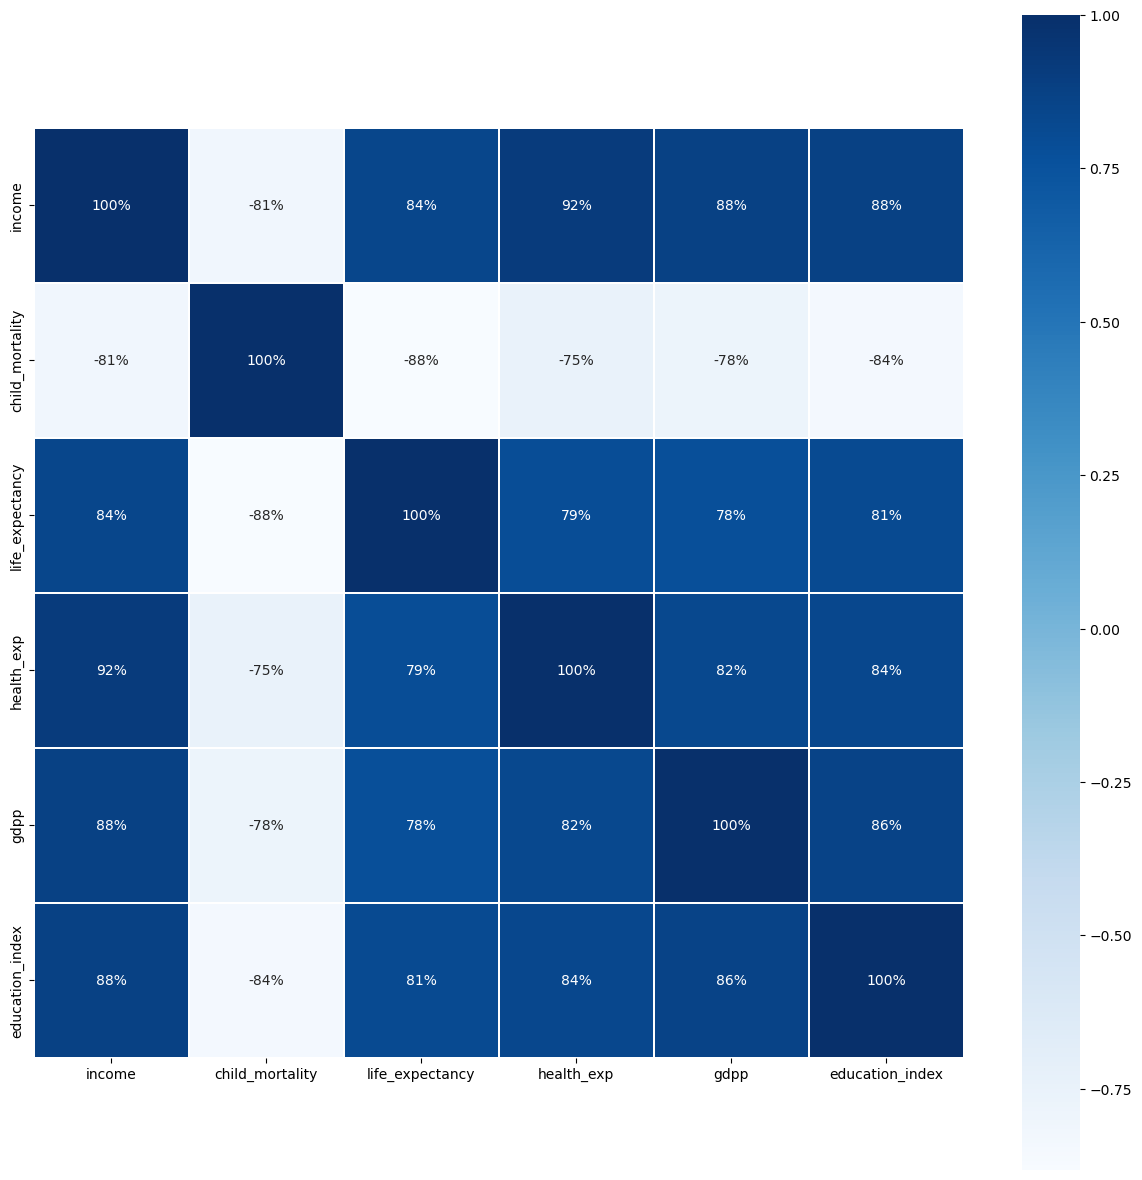

In [11]:
cm = df_only_numerical.corr()
plt.figure(figsize = (15,15))
heatmap(cm, annot = True, fmt = ".0%", cmap = "Blues", linewidths = 0.05, square = True, linecolor = "white")
plt.show()

From the descriptive statistic we see there seems to be missing values from years 5 and down, this can also be seen in the scatter plots. We see alot of linear relationships and high correlation both positive and negative. Two key patterns we see is that both Gdp and education seem to have a linear relationship with all the other variables

### Task 3

In [12]:
# Scaling
scaler = MinMaxScaler(feature_range = (0, 1))

In [13]:
scaler = scaler.fit(df_only_numerical)
df_scaled = scaler.transform(df_only_numerical)

In [14]:
df_scaled = pd.DataFrame(df_scaled, columns = df_only_numerical.columns)
df_scaled.head()

,income,child_mortality,life_expectancy,health_exp,gdpp,education_index
0,0.863210,0.000000,0.796691,0.622143,0.677276,0.843898
1,0.393348,0.176055,0.524064,0.260273,0.260986,0.527399
2,0.284529,0.272197,0.543977,0.228511,0.221214,0.549593
3,0.219688,0.241680,0.471578,0.209836,0.318353,0.541257
4,0.308166,0.194934,0.593870,0.198771,0.210731,0.455918


We see now the variables are scaled from 0 - 1, this helps our models train better because it limits bias towards high values

### Task 4

In [15]:
# We create a list of the inertia scores, this is the sum of the distances from all points to the cluster center points 

cl_data = df_scaled 

Score_list = []
k_range = range(1, 30)

for k in k_range:
    model = KMeans(n_clusters = k, n_init = "auto", random_state = 42)
    model = model.fit(cl_data)
    Score_list.append(model.inertia_)

C:\Programs\Anaconda3\2025.06\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Programs\Anaconda3\2025.06\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Programs\Anaconda3\2025.06\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Programs\Anaconda3\2025.06\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~

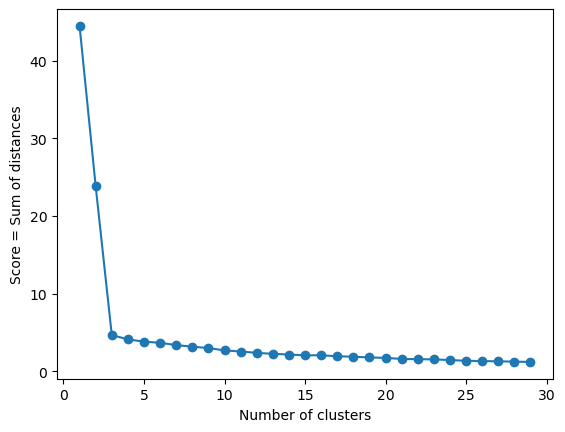

In [16]:
plt.plot(k_range, Score_list, marker = "o")
plt.xlabel("Number of clusters")
plt.ylabel("Score = Sum of distances")
plt.show()

After 3 clusters there is a clear drop of, this looks like the elbow point

In [17]:
# Looking at silhouette score aswell

Score_list = []
k_range = range(2, 30)

for k in k_range:
    model = KMeans(n_clusters = k, n_init = "auto", random_state = 42)
    model = model.fit(cl_data)
    Score_list.append(silhouette_score(cl_data, model.labels_))

C:\Programs\Anaconda3\2025.06\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Programs\Anaconda3\2025.06\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Programs\Anaconda3\2025.06\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Programs\Anaconda3\2025.06\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

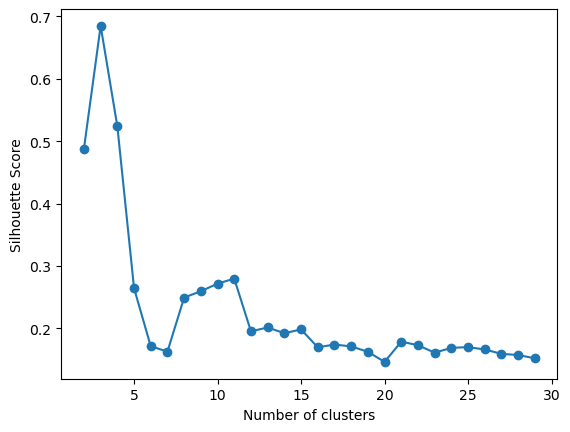

In [18]:
plt.plot(k_range, Score_list, marker = "o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

After both plots it seems like 3 clusters is the most fitting, here you could also make a case for 2 because the silhouette score is higher, but combined 3 seems like the best choice

In [19]:
# Implement the model with 3 clusters

model_KM = KMeans(n_clusters = 3, random_state = 42)

In [20]:
# Assign the countries a AC label
KM_labels = model_KM.fit_predict(cl_data)
df["KM_label"] = KM_labels
df.head()

C:\Programs\Anaconda3\2025.06\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,country,income,child_mortality,life_expectancy,health_exp,gdpp,education_index,KM_label
0,Country_1,59.516847,5.000000,82.853065,3322.946051,55.382380,0.887083,2
1,Country_2,29.046532,19.916584,70.829731,1438.011786,22.069371,0.611301,0
2,Country_3,21.989635,28.062344,71.707952,1272.570648,18.886684,0.630639,0
3,Country_4,17.784780,25.476721,68.515032,1175.294320,26.660145,0.623375,0
4,Country_5,23.522533,21.516141,73.908315,1117.656228,18.047816,0.549015,0


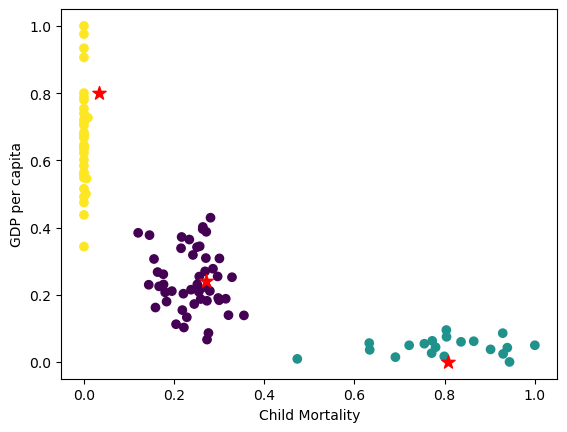

In [22]:
plt.scatter(df_scaled["child_mortality"], df_scaled["gdpp"], c = KM_labels)
plt.scatter(model_KM.cluster_centers_[:,0],model_KM.cluster_centers_[:,1],  color = "red", marker = "*", s = 100)
plt.xlabel("Child Mortality")
plt.ylabel("GDP per capita")
plt.show()

In this plot we see our model did pretty well, however it seems like the cap on children mortality did create some noise. This clusters together alot of countries that struggle with general health so it seems usefull to keep it like this

### Task 5

In [23]:
# Now we will use Agglomerative Clustering
model_AC = AgglomerativeClustering(n_clusters = 3)
model_AC = model_AC.fit(cl_data)

In [25]:
# Assign the countries a AC label
AC_labels = model_AC.fit_predict(cl_data)
df["AC_Label"] = AC_labels
df.head()

,country,income,child_mortality,life_expectancy,health_exp,gdpp,education_index,KM_label,AC_Label
0,Country_1,59.516847,5.000000,82.853065,3322.946051,55.382380,0.887083,2,0
1,Country_2,29.046532,19.916584,70.829731,1438.011786,22.069371,0.611301,0,1
2,Country_3,21.989635,28.062344,71.707952,1272.570648,18.886684,0.630639,0,1
3,Country_4,17.784780,25.476721,68.515032,1175.294320,26.660145,0.623375,0,1
4,Country_5,23.522533,21.516141,73.908315,1117.656228,18.047816,0.549015,0,1


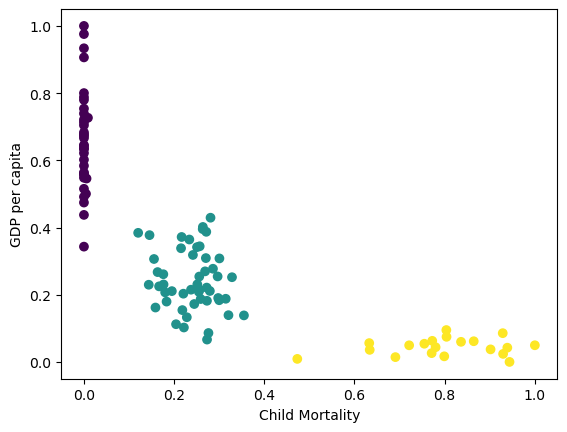

In [26]:
plt.scatter(df_scaled["child_mortality"], df_scaled["gdpp"], c = AC_labels)
plt.xlabel("Child Mortality")
plt.ylabel("GDP per capita")
plt.show()

The AC models seems to have found the same clusters as the KM model

In [27]:
df.head(15)

,country,income,child_mortality,life_expectancy,health_exp,gdpp,education_index,KM_label,AC_Label
0,Country_1,59.516847,5.000000,82.853065,3322.946051,55.382380,0.887083,2,0
1,Country_2,29.046532,19.916584,70.829731,1438.011786,22.069371,0.611301,0,1
2,Country_3,21.989635,28.062344,71.707952,1272.570648,18.886684,0.630639,0,1
3,Country_4,17.784780,25.476721,68.515032,1175.294320,26.660145,0.623375,0,1
4,Country_5,23.522533,21.516141,73.908315,1117.656228,18.047816,0.549015,0,1
5,Country_6,7.591744,71.075289,50.574826,377.973461,4.689482,0.388622,1,2
6,Country_7,6.970899,58.695268,56.080229,687.634735,4.057751,0.352411,1,2
7,Country_8,20.419133,26.302211,67.882185,1129.290335,19.657720,0.433038,0,1
8,Country_9,61.550221,5.000000,76.970696,3696.727714,39.140167,0.856203,2,0
9,Country_10,49.226100,5.000000,85.364890,3004.753682,47.904201,0.822162,2,0


If we look at only the plots it seems like there is no diffrence between the models, when looking at the labels this also seems to be the case. However label 0 for the KM is label 1 for the AC and so on. Both models perform very well, atleast based on the plots we have seen. This makes sense when looking at the scatter plots from task 2 because already here we see there are some clear clusters. Clustering models perform well with high correletion and as we see here both models show that the data set contain 3 clear clusters. An important thing to note is again that the child mortality seems to have high importance in both models, but for this task about allocating money, it seems logical to keep it like this

In [58]:
KM_silhouette = silhouette_score(cl_data, df["KM_label"])
AC_silhouette = silhouette_score(cl_data, df["AC_Label"])

print("Silhouette score on KMeans model:", KM_silhouette)
print("Silhouette score on AC model:", AC_silhouette)

Silhouette score on KMeans model: 0.6848676767172324
Silhouette score on AC model: 0.6848676767172324


We see the silhouette score on both models are the same aswell. Both having a 0.685 means they are almost considered strong and over the reasonable 0.5 value

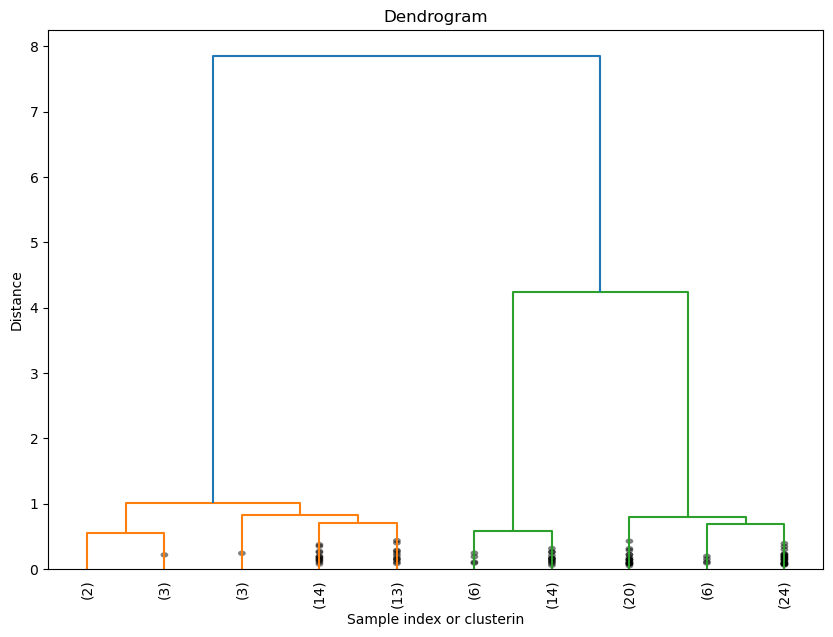

In [62]:
# Dendrogram plot
z = linkage(cl_data, method = "ward")
plt.figure(figsize = (10, 7))

dendrogram(z, truncate_mode = "lastp", p = 10, leaf_rotation = 90, leaf_font_size = 10, show_contracted = True)
plt.title("Dendrogram")
plt.xlabel("Sample index or clusterin")
plt.ylabel("Distance")
plt.show()


According to this plot 3 still seems to be the right amount of clusters, however a case could be made here for 2 aswell

### Task 6

In [67]:
# For this task I am going to try 3 diffrent DBSCAN models
X = df_scaled
y = df["country"] 

model_DBSCAN_1 = DBSCAN(eps = 0.1, min_samples = 3)

y_pred_DBSCAN_1 = model_DBSCAN_1.fit_predict(X)

print(y_pred_DBSCAN_1[0:50])

core_points_1 = np.zeros_like(y_pred_DBSCAN_1, dtype=bool)
core_points_1[model_DBSCAN_1.core_sample_indices_] = True

print(len(core_points_1))

[ 2 -1  0  0  1 -1 -1 -1 -1 -1  2 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1  1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0 -1 -1
 -1 -1]
105


In [68]:
model_DBSCAN_2 = DBSCAN(eps = 0.5, min_samples = 5)

y_pred_DBSCAN_2 = model_DBSCAN_2.fit_predict(X)

print(y_pred_DBSCAN_3[0:50])

core_points_2 = np.zeros_like(y_pred_DBSCAN_2, dtype=bool)
core_points_2[model_DBSCAN_2.core_sample_indices_] = True

print(len(core_points_2))

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1]
105


In [73]:
model_DBSCAN_3 = DBSCAN(eps = 100, min_samples = 4)

y_pred_DBSCAN_3 = model_DBSCAN_3.fit_predict(X)

print(y_pred_DBSCAN_3[0:50])

core_points_3 = np.zeros_like(y_pred_DBSCAN_3, dtype=bool)
core_points_3[model_DBSCAN_3.core_sample_indices_] = True

print(len(core_points_3))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
105


Based on the predictions seems like model 2 is performing best because it has more core points meaning 0s in the array. All the models seem to create 105 core points based on the print, however I unfortunatly have no explanation for this so I choose model based on the arrays 

In [51]:
df["DBSCAN_Label"] = y_pred_DBSCAN
df.head() 

,country,income,child_mortality,life_expectancy,health_exp,gdpp,education_index,KM_label,AC_Label,DBSCAN_Label
0,Country_1,59.516847,5.000000,82.853065,3322.946051,55.382380,0.887083,2,0,2
1,Country_2,29.046532,19.916584,70.829731,1438.011786,22.069371,0.611301,0,1,-1
2,Country_3,21.989635,28.062344,71.707952,1272.570648,18.886684,0.630639,0,1,0
3,Country_4,17.784780,25.476721,68.515032,1175.294320,26.660145,0.623375,0,1,0
4,Country_5,23.522533,21.516141,73.908315,1117.656228,18.047816,0.549015,0,1,1


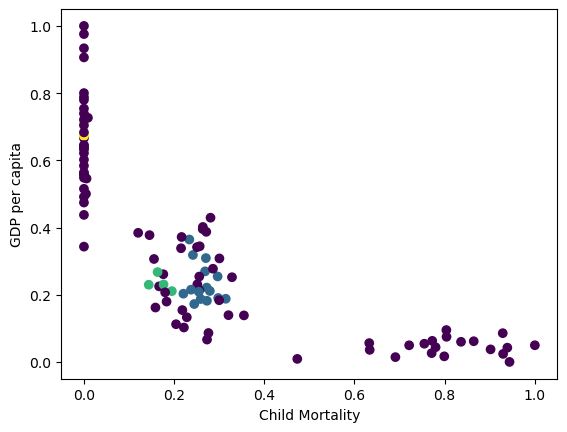

In [54]:
plt.scatter(df_scaled["child_mortality"], df_scaled["gdpp"], c = y_pred_DBSCAN)
plt.xlabel("Child Mortality")
plt.ylabel("GDP per capita")
plt.show()

it seems like the DBSCAN did worse then the other clustering models, this may be because the eps or the max distance was too narrow. On a dataset like this one where there are alot of linear relationships this makes sense because for those type of clustering problems the DBSCAN wil often get outperformed by KMeans and Agglomerative

In [79]:
# I assume this task could be solved using the same Score_list as the other clusters however I could not get the code to work.

### Task 7

The countries in the clusters represented by 2/0 by the KM/AC labels are clearly the ones in greatest need, however the ones in cluster represented by 0/1 by the KM/AC labels seems to need some help aswell. Therefore I would like to propose an allocation of 8,5 million to the countries in the cluster 2/0 and 1,5 million to the countries in the 0/1 cluster.